# Systematic Signals Across Global Equity Index Futures

## Project objective

This notebook revisits and extends a Columbia course project on systematic factor-mimicking portfolios across **10 developed-country equity index futures**.

The original project was implemented in Excel according to course requirements. I am rebuilding the analysis in Python so that the methodology is easier to inspect, test, and extend.

The goals of the revised project are to:

1. reconstruct the original factor-portfolio methodology;
2. test several economically motivated signal definitions;
3. separate **signal construction** from **risk scaling**;
4. evaluate robustness without selecting specifications solely because they produce better historical performance;
5. document both successful and unsuccessful hypotheses honestly.

## 1. Data

The professor supplied approximately 50 years of monthly return data for a universe explicitly described in the assignment as **10 developed-country equity index futures**.

I did **not** construct the underlying continuous futures return series myself. The supplied material does not establish details such as contract-selection rules or roll conventions.

Accordingly, this project begins with the **course-provided monthly return series**. The research contribution is in signal construction, factor-mimicking portfolio construction, covariance estimation, volatility targeting, portfolio combination, and backtesting.

### Return and timing convention

Let $r_{i,t}$ denote the return of market $i$ **during month $t$**, measured from the end of month $t-1$ to the end of month $t$.

The backtest follows the timing convention:

1. observe returns and other information through the end of month $t$;
2. construct the signal at the end of month $t$;
3. use that signal to determine the portfolio weight for month $t + 1$;
4. the resulting portfolio earns the return realized during month $t + 1$.

Therefore,

$$
\text{information through }t
\rightarrow
\text{signal at }t
\rightarrow
\text{weight for }t+1
\rightarrow
r_{i,t+1}.
$$

This convention ensures that all portfolio weights are based only on information available before the corresponding holding-period return is realized.

Each observation in the supplied dataset is treated as a **raw monthly return**, not an annualized monthly statistic.

For example, if monthly returns over a 12-month window are

$$
r_{i,t-11},\ldots,r_{i,t},
$$

then the compounded return over that period is

$$
\prod_{k=t-11}^{t}(1+r_{i,k})-1.
$$

## 2. Signal construction

All signals are constructed **cross-sectionally** at the end of each month.

Here, *cross-sectional* means that the 10 markets are compared with one another at the **same point in time**. The signals are therefore relative measures: the question is not only whether one market has a high or low raw signal value, but how strong that signal is relative to the rest of the investment universe.

A generic cross-sectional z-score is

$$
z_{i,t}
=
\frac{x_{i,t}-\bar{x}_t}{\sigma_t},
$$

where:

* $x_{i,t}$ is market $i$'s signal value at the end of month $t$;
* $\bar{x}_t$ is the cross-sectional mean across the 10 markets;
* $\sigma_t$ is the cross-sectional standard deviation.

The z-score determines the **raw factor weight for the following month**:

$$
w_{i,t+1}=z_{i,t}.
$$

Because the cross-sectional mean is subtracted,

$$
\sum_i w_{i,t+1}=0,
$$

so the raw factor-mimicking portfolio is naturally **long/short and dollar-neutral**.

Dividing by the cross-sectional standard deviation standardizes the dispersion of weights. A market one cross-sectional standard deviation above the group average receives the same standardized signal regardless of whether the raw signals are tightly clustered or widely dispersed in that month.

For cross-sectional z-score normalization, I use the **population standard deviation** (`ddof=0`). The 10 markets constitute the full defined investment universe rather than a sample used to estimate the dispersion of some larger population. This choice affects only the common scale of the raw factor-weight vector and should not affect the final portfolio after the entire vector is subsequently rescaled to a fixed volatility target.

### 2.1 Interpretation of portfolio weights

The factor weights are interpreted as signed notional exposures relative to a reference capital level.

If $C$ denotes reference capital, the notional exposure to market $i$ during month $t$ is

$$
N_{i,t}
=
C w_{i,t}.
$$

Because the factor weights are cross-sectionally demeaned,

$$
\sum_i w_{i,t}=0,
$$

and therefore the portfolio has zero net notional exposure:

$$
\sum_i N_{i,t}=0.
$$

However, gross notional exposure is

$$
C\sum_i |w_{i,t}|,
$$

which is generally positive and need not equal the reference capital.

The reference capital therefore serves as a normalization for translating portfolio returns, P&L, and turnover into dollar quantities. It should not be interpreted as the market value of the long and short positions or as a reconstruction of the cash or margin required to implement the futures portfolio.

### 2.2 Factor: momentum

**Economic intuition:** buy medium-term winners and sell medium-term losers.

I test two pre-specified momentum definitions.

#### Variant A: trailing 12-month momentum

At the end of month $t$, the trailing 12-month compounded return is

$$
M_{i,t}
=
\prod_{k=t-11}^{t}(1+r_{i,k})-1.
$$

This uses the returns from months

$$
t-11,\ldots,t.
$$

The corresponding raw portfolio weight for month $t+1$ is

$$
w^{\text{mmtm}}_{i,t+1}
=
z_t\left(M_{i,t}\right).
$$

Thus, markets with stronger trailing returns receive positive weights and markets with weaker trailing returns receive negative weights.

#### Variant B: momentum excluding the most recent month

A common stock-momentum convention excludes the most recent month because very recent individual-stock returns can exhibit short-term reversal and microstructure effects. That intuition may be weaker for country-level equity index futures, so I treat this as an alternative specification rather than assume it is superior.

At the end of month $t$,

$$
M^{\text{skip-one}}_{i,t}
=
\prod_{k=t-11}^{t-1}(1+r_{i,k})-1.
$$

This uses 11 monthly returns and excludes month $t$.

The corresponding raw weight for month $t+1$ is

$$
w^{\text{mmtm-skip-one}}_{i,t+1}
=
z_t\left(M^{\text{skip-one}}_{i,t}\right).
$$

The two specifications are compared as a robustness exercise rather than by selecting whichever happens to produce the best historical performance.

### 2.3 Factor: low volatility

**Economic intuition:** buy lower-risk markets and sell higher-risk markets.

For each market, risk is estimated using information available through the end of month $t$. The 10 markets are then ranked **from highest risk to lowest risk**:

* highest risk → rank 1;
* lowest risk → rank 10.

The ranks are converted into cross-sectional z-scores.

Therefore:

* lower-risk markets receive positive weights;
* higher-risk markets receive negative weights.

The raw low-risk portfolio weight for month $t+1$ is

$$
w^{\text{low-risk}}_{i,t+1}
=
z_t(\text{rank}_{i,t}).
$$

Using ranks rather than raw risk values makes the signal depend on relative ordering rather than the magnitude of differences in risk, reducing sensitivity to extreme observations at the cost of discarding information about how far apart risk levels are.

Tied markets receive the average of the ranks they occupy.

I test two measures of trailing risk.

#### Variant A: total volatility

Trailing 12-month volatility is estimated using the sample standard deviation:

$$
\hat\sigma_{i,t}
=
\operatorname{SD}
\left(
r_{i,t-11},\ldots,r_{i,t}
\right).
$$

The sample standard deviation (`ddof=1`) is used because the observed monthly returns can be viewed as a sample from the market's underlying return-generating process.

The markets are ranked by $\hat\sigma_{i,t}$ in descending order and the ranks are converted into z-scores.

#### Variant B: zero-target downside deviation

Total volatility treats upside and downside variation symmetrically. As an alternative, I use a downside-risk measure in which positive-return months contribute zero.

For market $i$,

$$
DD_{i,t}
=
\sqrt{
\frac{1}{12}
\sum_{k=t-11}^{t}
\min(r_{i,k},0)^2
}.
$$

Interpretation:

* positive monthly returns contribute zero;
* negative monthly returns contribute their squared magnitude;
* the squared shortfalls are averaged over all 12 months;
* the square root converts the measure back into return units.

This is a lower-partial-moment-style downside measure relative to a zero target, rather than an ordinary sample standard deviation.

The 10 markets are ranked by $DD_{i,t}$ in descending order, and the ranks are converted into z-scores to obtain the raw weights for month $t+1$.

### 2.4 Factor: short-term reversal

**Economic intuition:** buy last month's losers and sell last month's winners.

At the end of month $t$, define the reversal signal as

$$
REV_{i,t}=-r_{i,t}.
$$

Thus:

* a negative return during month $t$ becomes a positive reversal signal;
* a positive return during month $t$ becomes a negative reversal signal.

The raw portfolio weight for month $t+1$ is

$$
w^{\text{rev}}_{i,t+1}
=
z_t\left(REV_{i,t}\right).
$$

Short-term reversal is well documented in individual equities, where liquidity, temporary price pressure, and microstructure effects can contribute to reversal. Those mechanisms need not generalize to country-level equity index futures, so this signal is treated as an empirical hypothesis rather than something assumed to work.

### 2.5 Note on pre-specified signal variants

To reduce specification mining, the signal variants covered in this section are defined **before examining the revised backtest results**:

| Signal family | Variant |
|---|---|
| Momentum | trailing 12-month compounded return |
| Momentum | trailing 11-month compounded return, skipping the most recent month |
| Low risk | trailing 12-month sample standard deviation |
| Low risk | trailing 12-month zero-target downside deviation |
| Reversal | negative of the most recent monthly return |

The purpose is to compare economically interpretable definitions and report the results honestly, not to choose the historically best-performing specification and discard the others.

## 3. Rolling covariance estimation

To estimate portfolio risk, I use a **rolling 36-month covariance matrix** of monthly returns.

Let

$$
R_t \in \mathbb{R}^{36 \times N}
$$

denote the matrix of monthly returns available through the end of month $t$, where:

* the 36 rows correspond to the most recent 36 months;
* the $N$ columns correspond to the $N$ markets in the investment universe.

For this project, $N=10$.

### 3.1 Local-stationarity assumption

Using a rolling covariance estimator implicitly assumes that the return-generating process is approximately stable within each 36-month window.

In particular, I assume that the mean vector and covariance structure are locally stable enough that the previous 36 monthly observations provide a reasonable estimate of the covariance matrix relevant for the next month's portfolio.

This is an approximation rather than a claim that expected returns, volatilities, and correlations are literally constant.

The 36-month window creates a bias-variance tradeoff:

* a shorter window adapts more quickly to changing volatility and correlation regimes but produces noisier covariance estimates;
* a longer window produces more stable estimates but responds more slowly to structural changes.

### 3.2 Demeaning the return matrix

Let

$$
\bar r_t \in \mathbb{R}^{N}
$$

be the vector of sample mean returns across the 36-month window.

The demeaned return matrix is

$$
X_t
=
R_t
-
\mathbf{1}_{36}\bar r_t^\top,
$$

where

$$
\mathbf{1}_{36}
$$

is a $36 \times 1$ vector of ones.

Thus, each column of $X_t$ contains one market's 36 monthly returns after subtracting that market's mean return over the same window.

### 3.3 Sample covariance matrix

The covariance matrix is estimated as

$$
\hat{\Sigma}_t
=
\frac{1}{35}
X_t^\top X_t.
$$

Because $X_t \in \mathbb{R}^{36 \times N}$,

$$
X_t^\top X_t
\in
\mathbb{R}^{N \times N}.
$$

The $(i,j)$-th element is

$$
(\hat{\Sigma}_t)_{ij}
=
\frac{1}{35}
\sum_{s=1}^{36}
(r_{i,s}-\bar r_i)
(r_{j,s}-\bar r_j).
$$

Therefore:

* diagonal elements estimate individual market variances;
* off-diagonal elements estimate pairwise covariances.

Equivalently, the $(i,j)$-th element of $X_t^\top X_t$ is the inner product between the demeaned return vectors of markets $i$ and $j$.

The denominator is $35=36-1$, rather than 36, because the mean vector is estimated from the same 36 observations. This is the standard sample-covariance normalization.

### 3.4 Annualization

The covariance matrix is estimated from monthly returns, so I annualize it using

$$
\hat{\Sigma}^{\text{ann}}_t
=
12\hat{\Sigma}_t.
$$

This annualization uses the standard approximation that monthly return vectors have negligible serial covariance and that the one-month covariance structure is locally representative of the annual horizon. Under these assumptions, covariance scales approximately linearly with time.

If $R_t$ and $R_s$ denote return vectors from different months, this assumes approximately that

$$
\operatorname{Cov}(R_t,R_s)=0
\qquad
\text{for } t\neq s.
$$

Under this assumption, covariance scales linearly with time, which implies

$$
\Sigma_{\text{annual}}
=
12\Sigma_{\text{monthly}}.
$$

Correspondingly, individual volatilities scale by

$$
\sigma_{\text{annual}}
=
\sqrt{12}\sigma_{\text{monthly}}.
$$

### 3.5 Role in portfolio construction

The full covariance matrix is retained because portfolio risk depends not only on individual market volatilities but also on how the markets co-move.

For a raw portfolio weight vector

$$
w_{t + 1} \in \mathbb{R}^{N},
$$

computed at the end of month $t$ and held during the month $t + 1$, the estimated annualized portfolio variance is

$$
\hat{\sigma}_{p,t + 1}^{2}
=
w_{t + 1}^\top
\hat{\Sigma}^{\text{ann}}_t
w_{t + 1},
$$

and portfolio volatility is

$$
\hat{\sigma}_{p,t+1}
=
\sqrt{
w_{t + 1}^\top
\hat{\Sigma}^{\text{ann}}_t
w_{t + 1}
}.
$$

This quantity is then used for volatility targeting and portfolio scaling.

Unlike the original Excel implementation, where rolling covariance matrices were largely embedded inside formulas and recomputed as needed, the Python implementation will retain each rolling covariance matrix explicitly for later inspection, debugging, and portfolio-risk calculations.

## 4. Targeting 1% portfolio volatility

After constructing a raw factor-mimicking portfolio, I rescale the entire weight vector so that its **estimated annualized portfolio volatility equals 1%**.

Let

$$
w_{t+1} \in \mathbb{R}^{N}
$$

denote the raw factor weights calculated at the end of month $t$ and held throughout month $t + 1$, and let

$$
\hat{\Sigma}^{\text{ann}}_t
$$

denote the annualized covariance matrix estimated using information available through month $t$.

For month $t + 1$, the estimated annualized volatility of the raw portfolio is

$$
\hat{\sigma}_{p,t + 1}
=
\sqrt{
w_{t+1}^\top
\hat{\Sigma}^{\text{ann}}_t
w_{t+1}
}.
$$

To target an annualized volatility of 1%, define the scaling factor

$$
c_{t + 1}
=
\frac{0.01}{\hat{\sigma}_{p,t + 1}}.
$$

The volatility-targeted portfolio weights are then

$$
\tilde w_{t + 1}
=
c_{t + 1} w_{t + 1}
=
w_{t + 1}
\frac{0.01}{\hat{\sigma}_{p,t + 1}}.
$$

This multiplies every position in the raw factor portfolio by the same scalar, so the relative structure of the portfolio is unchanged.

For example:

* if the raw portfolio has estimated annualized volatility of 8%, then

$$
c_{t + 1}
=
\frac{0.01}{0.08}
=
0.125,
$$

so every raw weight is multiplied by 0.125;

* if the raw portfolio has estimated annualized volatility of 0.5%, then

$$
c_{t + 1}
=
\frac{0.01}{0.005}
=
2,
$$

so every raw weight is doubled.

The resulting portfolio has estimated annualized volatility of exactly 1% under the same covariance estimate because

$$
\begin{aligned}
\operatorname{Var}(\tilde w_{t + 1})
&=
\tilde w_{t + 1}^\top
\hat{\Sigma}^{\text{ann}}_t
\tilde w_{t + 1} \\
&=
\left(
\frac{0.01}{\hat{\sigma}_{p,t + 1}}
\right)^2
w_{t + 1}^\top
\hat{\Sigma}^{\text{ann}}_t
w_{t + 1} \\
&=
\left(
\frac{0.01}{\hat{\sigma}_{p,t + 1}}
\right)^2
\hat{\sigma}_{p,t + 1}^2 \\
&=
0.01^2.
\end{aligned}
$$

Therefore,

$$
\sqrt{
\operatorname{Var}(\tilde w_{t + 1})
}
=
0.01.
$$

The volatility target is expressed relative to the portfolio's reference capital. Thus, a 1% annualized volatility target means that the volatility of factor P&L, divided by reference capital, is targeted at 1% per year. It does not imply that gross notional exposure equals 1% or 100% of reference capital.

## 5. Python implementation

The following code generates weights and returns for 1% ex-ante volatility factor portfolios.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# load returns data
returns = pd.read_excel("Returns.xlsx", index_col=0, parse_dates=True)
returns = returns.rename(columns=lambda x: x.replace("MSCI ", "").split(" NR ")[0])

In [2]:
# Data quality checks
assert returns.index.is_monotonic_increasing, "Dates are not sorted"
assert returns.index.is_unique, "Duplicate dates found"
print(returns.shape, returns.index.min().date(), "→", returns.index.max().date())
print("non-missing markets per month:", returns.notna().sum(axis=1).value_counts().to_dict())
returns.head()

(635, 10) 1970-01-31 → 2022-11-30
non-missing markets per month: {10: 635}


,Australia,Canada,France,Germany,Italy,Japan,Netherlands,Spain,United Kingdom,USA
Name,,,,,,,,,,
1970-01-31,-0.031330,0.024480,0.038060,-0.048350,0.041000,-0.015471,-0.054510,0.039030,-0.007390,-0.072024
1970-02-28,-0.011542,0.044393,-0.027917,-0.029265,-0.027224,0.012680,0.008408,0.048728,-0.053596,0.055510
1970-03-31,-0.003384,0.010206,-0.011684,0.008811,0.035392,0.041257,0.013425,-0.030698,0.024452,0.005203
1970-04-30,-0.111952,-0.114342,-0.059632,-0.046194,-0.002880,-0.118091,-0.062562,-0.080656,-0.102288,-0.087283
1970-05-31,-0.064832,-0.095029,-0.027265,-0.093870,-0.094636,-0.024622,-0.024288,-0.046147,-0.050362,-0.057233


In [3]:
# Define helper functions
def get_zscore(signal: pd.DataFrame) -> pd.DataFrame:
    row_mean = signal.mean(axis=1)
    row_std = signal.std(axis=1, ddof=0)
    return signal.sub(row_mean, axis=0).div(row_std, axis=0)

def scale_to_target_vol(weights: pd.DataFrame, cov_ann: pd.DataFrame, target_vol: float = 0.01) -> pd.DataFrame:
    scaled_weights = pd.DataFrame(np.nan, index=weights.index, columns=weights.columns)
    for date in weights.index:
        weight = weights.loc[date]
        cov = cov_ann.loc[date]
        if weight.isna().any() or cov.isna().values.any():
            continue
        vol = np.sqrt(weight @ cov @ weight)
        if np.isclose(vol, 0):
            continue
        scaled_weights.loc[date] = weight * target_vol / vol
    return scaled_weights

In [4]:
# Momentum signals and weights
mmtm_12m = (1 + returns).rolling(12).apply(np.prod, raw=True) - 1
mmtm_12m_skip1 = (1 + returns.shift(1)).rolling(11).apply(np.prod, raw=True) - 1  # Skip the most recent month
weights_mmtm_12m = get_zscore(mmtm_12m)
weights_mmtm_12m_skip1 = get_zscore(mmtm_12m_skip1)

# Low volatility signals and weights
vol_12m = returns.rolling(12).std(ddof=1)
vol_12m_rank = vol_12m.rank(axis=1, ascending=False, method='average')
weights_low_vol_12m = get_zscore(vol_12m_rank)

dd_12m = returns.clip(upper=0).pow(2).rolling(12).mean().pow(0.5)
dd_12m_rank = dd_12m.rank(axis=1, ascending=False, method='average')
weights_low_dd_12m = get_zscore(dd_12m_rank)

# Reversal signal and weights
weights_rev = get_zscore(-returns)

# Collect them into a dictionary of weights
# Note that upon manual inspection, the weights match my independent Excel implementation in FMP.xlsx
weights = {
    'mmtm_12m': weights_mmtm_12m,
    'mmtm_12m_skip1': weights_mmtm_12m_skip1,
    'low_vol': weights_low_vol_12m,
    'low_dd': weights_low_dd_12m,
    'rev': weights_rev
}

In [5]:
# Generate covariance matrices
cov_36m_ann = returns.rolling(36).cov(ddof=1) * 12

# Generate scaled portfolio weights
scaled_weights = {k: scale_to_target_vol(v, cov_36m_ann, 0.01) for k, v in weights.items()}

# Calculate target volatility portfolio returns
# Each row t of scaled_weights contains the positions chosen at the end of month t for holding during month t+1.
# Shift by one row to align those positions with the returns they earn.
target_vol_returns = {k: (v.shift(1) * returns).sum(axis=1, min_count=1) for k, v in scaled_weights.items()}

## 6. Result analysis

This section evaluates the realized performance of the constructed factor portfolios.

Portfolio returns are interpreted as monthly P&L relative to a fixed reference capital level. For a reference capital $C$ and portfolio return $r_{p,t}$,

$$
\text{PnL}_t = C r_{p,t}.
$$

The reference capital is held fixed when translating normalized factor returns into dollar P&L. Therefore, cumulative P&L is calculated additively rather than by compounding portfolio returns:

$$
\text{Cumulative PnL}_T
=
C\sum_{t=1}^{T} r_{p,t}.
$$

This convention avoids interpreting the backtest as a fully specified funded futures account with reinvested profits, margin requirements, collateral returns, and contract-roll mechanics, none of which can be reconstructed from the supplied return series.

The analysis focuses on four questions:

1. **Did volatility targeting work?**  
   How closely does realized annualized volatility match the 1% ex-ante target?

2. **How did the five signals perform?**  
   We compare average returns, realized volatility, risk-adjusted performance, statistical significance, and cumulative P&L.

3. **How sensitive are the results to rebalancing costs?**  
   We estimate changes in target notional exposure and examine performance under several illustrative transaction-cost assumptions.

4. **Do the factor portfolios provide diversification?**  
   We examine correlations among factor returns and their relationships with U.S. equity returns before considering simple factor combinations.

### 6.1 Cumulative P&L on Fixed Reference Capital

To visualize the economic magnitude of the factor returns, I use a fixed reference capital of $1 million.

For each month,

$$
\text{PnL}_t
=
\$1{,}000{,}000 \times r_{p,t},
$$

and cumulative P&L is

$$
\text{Cumulative PnL}_T
=
\$1{,}000{,}000
\sum_{t=1}^{T} r_{p,t}.
$$

Profits and losses are therefore not reinvested into the strategy. The $1 million amount simply fixes the scale used to translate normalized factor returns into dollar P&L.

This differs from a compounded wealth or NAV calculation, which would implicitly assume that future notional exposures are scaled with the portfolio's changing accumulated value.

In [6]:
# Check data integrity before we call dropna
for k, r in target_vol_returns.items():
    interior_gaps = r.loc[r.first_valid_index():].isna().sum()
    assert interior_gaps == 0, f'{k}: {interior_gaps} interior NaN months'

# Set up reference capital
capital = 1_000_000

# Compute cumulative PnL
c_pnl = {}
for factor, r in target_vol_returns.items():
    r = r.dropna()
    factor_pnl = capital * r.cumsum()

    # Explicit starting point: zero cumulative P&L
    init_date = r.index[0] - pd.offsets.MonthEnd(1)
    factor_pnl = pd.concat([pd.Series([0.0], index=[init_date]), factor_pnl])
    c_pnl[factor] = factor_pnl

# Build DataFrame from dictionary for easy visualization
# Use descriptive names for the legend
factor_names = {
    'mmtm_12m': '12M Momentum',
    'mmtm_12m_skip1': '12M Momentum (Skip 1)',
    'low_vol': 'Low Volatility',
    'low_dd': 'Low Downside Deviation',
    'rev': '1M Reversal'
}
c_pnl_df = pd.DataFrame(c_pnl).rename(columns=factor_names)

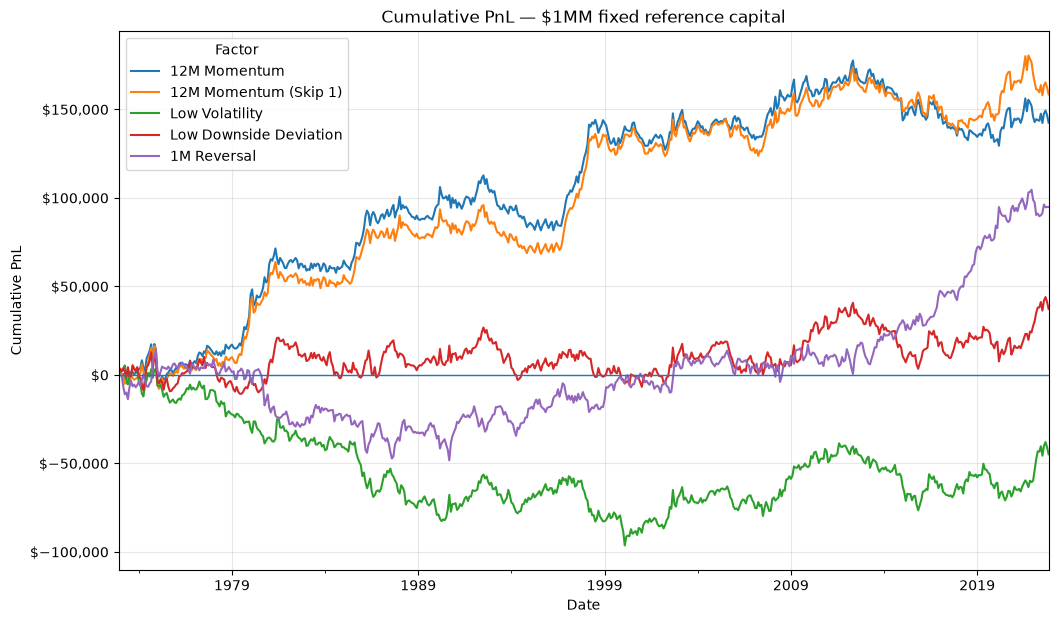

In [7]:
ax = c_pnl_df.plot(figsize=(12, 7))
ax.axhline(0, linewidth=1)
ax.set_title("Cumulative PnL — $1MM fixed reference capital")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative PnL")
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.grid(True, alpha=0.3)
ax.legend(title="Factor")

plt.show()

### 6.2 Portfolio Statistics

The factor portfolios are evaluated over their common monthly return sample.

The reported statistics are:

- **Annualized arithmetic mean return:** the average monthly factor return multiplied by 12. Since monthly returns represent P&L relative to fixed reference capital, this is also the annualized average P&L rate relative to that reference capital.

- **Realized annualized volatility:** the sample standard deviation of monthly factor returns multiplied by $\sqrt{12}$. This is compared with the 1% ex-ante volatility target used in portfolio construction.

- **Sharpe ratio:** annualized arithmetic mean factor return divided by realized annualized volatility. Because the portfolios represent dollar-neutral active factor P&L, zero is used as the benchmark for the factor return. This does not imply that historical cash interest rates were zero.

- **Mean-return t-statistic:** a test of

$$
H_0:\mu=0,
$$

where $\mu$ is the expected monthly factor return. The conventional statistic is

$$
t
=
\frac{\bar r}{s/\sqrt{n}},
$$

where $\bar r$ is the sample mean, $s$ is the sample standard deviation, and $n$ is the number of monthly observations. This is the conventional iid standard error and does not adjust for possible serial correlation or heteroskedasticity.

- **Maximum cumulative-P&L drawdown:** the largest decline in cumulative P&L from a previous cumulative-P&L peak, expressed as a percentage of the fixed reference capital.

- **Final cumulative P&L:** the sum of monthly dollar P&L generated on the fixed $1 million reference capital.

Because reference capital is fixed rather than reinvested, geometric mean return and compounded final portfolio value are not reported.

In [8]:
stats = {}

for factor, r in target_vol_returns.items():
    r = r.dropna()
    n_months = len(r)
    n_years = n_months / 12

    # Annualized arithmetic mean return
    ann_ar_mean_return = r.mean() * 12

    # Realized annualized volatility
    ann_vol = r.std(ddof=1) * np.sqrt(12)

    # Sharpe ratio
    sharpe = ann_ar_mean_return / ann_vol

    # Conventional iid t-statistic for mean monthly return
    t_stat = r.mean() / (r.std(ddof=1) / np.sqrt(n_months))

    # Fixed-reference-capital P&L
    monthly_pnl = capital * r
    factor_cumu_pnl = monthly_pnl.cumsum()
    factor_cumu_pnl = pd.concat([
        pd.Series([0.0], index=[r.index[0] - pd.offsets.MonthEnd(1)]),
        factor_cumu_pnl
    ])

    # Peak-to-trough cumulative-P&L drawdown
    running_max_pnl = factor_cumu_pnl.cummax()
    pnl_drawdown = factor_cumu_pnl - running_max_pnl
    max_pnl_drawdown_pct = pnl_drawdown.min() / capital
    final_pnl = factor_cumu_pnl.iloc[-1]

    # Store statistics for this factor
    stats[factor] = {
        'Number of Months': n_months,
        'Number of Years': n_years,
        'Annualized Arithmetic Return': ann_ar_mean_return,
        'Realized Annualized Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Mean Return t-Statistic': t_stat,
        'Max PnL Drawdown / Reference Capital': max_pnl_drawdown_pct,
        'Final Cumulative PnL': final_pnl
    }

# Construct a DataFrame from the stats dict
stats_df = pd.DataFrame.from_dict(stats, orient='index').rename(index=factor_names)  # Each key (factor) will be one row
stats_df.index.name = 'Factor'

In [9]:
stats_df

,Number of Months,Number of Years,Annualized Arithmetic Return,Realized Annualized Volatility,Sharpe Ratio,Mean Return t-Statistic,Max PnL Drawdown / Reference Capital,Final Cumulative PnL
Factor,,,,,,,,
12M Momentum,599,49.916667,0.002853,0.011175,0.255318,1.803867,-0.048162,142419.906371
12M Momentum (Skip 1),599,49.916667,0.003172,0.011212,0.282938,1.999009,-0.037249,158348.657119
Low Volatility,599,49.916667,-0.000901,0.009818,-0.091771,-0.648377,-0.101690,-44976.036476
Low Downside Deviation,599,49.916667,0.000744,0.010419,0.071432,0.504676,-0.037297,37149.049438
1M Reversal,599,49.916667,0.001897,0.010185,0.186273,1.316049,-0.062505,94699.086289


The table below summarizes the performance of the five factor portfolios over the common 599-month evaluation period, corresponding to approximately 49.9 years of realized portfolio returns.

The underlying statistics are kept in numeric form for subsequent analysis, while the displayed table is formatted for readability. Percentage-based quantities such as annualized returns, realized volatility, and maximum drawdown are shown as percentages; Sharpe ratios and t-statistics are rounded to two decimal places; and final cumulative P&L values are displayed in dollar terms.

Because all five portfolios are evaluated over the same sample period, the number of months and years are omitted from the displayed table to avoid redundant columns.

In [10]:
display_cols = [
    'Annualized Arithmetic Return',
    'Realized Annualized Volatility',
    'Sharpe Ratio',
    'Mean Return t-Statistic',
    'Max PnL Drawdown / Reference Capital',
    'Final Cumulative PnL'
]

stats_display = stats_df[display_cols]

stats_display.style.format({
    'Annualized Arithmetic Return': '{:.2%}',
    'Realized Annualized Volatility': '{:.2%}',
    'Sharpe Ratio': '{:.2f}',
    'Mean Return t-Statistic': '{:.2f}',
    'Max PnL Drawdown / Reference Capital': '{:.2%}',
    'Final Cumulative PnL': '${:,.0f}'
})

,Annualized Arithmetic Return,Realized Annualized Volatility,Sharpe Ratio,Mean Return t-Statistic,Max PnL Drawdown / Reference Capital,Final Cumulative PnL
Factor,,,,,,
12M Momentum,0.29%,1.12%,0.26,1.80,-4.82%,"$142,420"
12M Momentum (Skip 1),0.32%,1.12%,0.28,2.00,-3.72%,"$158,349"
Low Volatility,-0.09%,0.98%,-0.09,-0.65,-10.17%,"$-44,976"
Low Downside Deviation,0.07%,1.04%,0.07,0.50,-3.73%,"$37,149"
1M Reversal,0.19%,1.02%,0.19,1.32,-6.25%,"$94,699"


The results show that the volatility-targeting procedure was broadly successful. Realized annualized volatility ranges from approximately 0.98% to 1.12% across the five portfolios, remaining reasonably close to the 1% ex-ante target. The difference between predicted and realized volatility is expected because portfolio weights are scaled using covariance estimates based on historical data, whereas the table reports volatility subsequently realized by the portfolios.

The two momentum specifications exhibit the strongest performance in the sample. The standard 12-month momentum strategy earns an annualized arithmetic return of 0.29% with a Sharpe ratio of 0.26, while the skip-most-recent-month specification earns 0.32% with a Sharpe ratio of 0.28. The latter also has a smaller maximum drawdown (-3.72% versus -4.82%) and a higher mean-return t-statistic. Its t-statistic of approximately 2.00 provides borderline evidence against the null hypothesis of a zero mean return under the conventional iid t-test. This should not, however, be interpreted as strong statistical evidence, particularly because the current t-statistic does not adjust for possible serial correlation or heteroskedasticity.

The low-volatility signal performs poorly in this universe. Despite achieving realized volatility very close to the target, it produces a negative annualized return, a negative Sharpe ratio, and the largest maximum drawdown among the five portfolios. This result provides evidence against the low-volatility factor as implemented here in this particular investment universe.

Using downside deviation instead of total volatility produces a materially different result. The low-downside-deviation portfolio generates a small positive return and a much smaller drawdown than the total-volatility specification, although its Sharpe ratio of 0.07 and t-statistic of 0.50 indicate weak performance overall. This suggests that distinguishing downside variation from total return variation may matter for this cross-sectional signal, but the historical evidence is limited.

The one-month reversal portfolio also produces a positive return, with an annualized arithmetic return of 0.19%, a Sharpe ratio of 0.19, and a t-statistic of 1.32. Its performance is weaker than that of the momentum portfolios over the full sample, but sufficiently different to motivate later examination of correlations across factor returns and possible diversification benefits.

Overall, the full-sample results favor the momentum specifications, while the low-volatility result is negative and the downside-deviation and reversal signals are weaker but positive. These comparisons are descriptive rather than a basis for selecting the historically best-performing factor, since the full historical sample has already been observed and subsequent specification choices should avoid being driven solely by realized backtest performance.

### 6.3 Target-Weight Turnover and Transaction-Cost Sensitivity

The gross factor returns calculated above do not explicitly deduct the costs associated with rebalancing the strategy.

Transaction costs associated with the supplied return series are not documented. I therefore model only the rebalancing costs arising from changes in the target-volatility-scaled portfolio weights.

At the end of month $t$, the portfolio changes from the target exposure held during month $t$,

$$
\tilde w_{i,t},
$$

to the target exposure chosen for month $t+1$,

$$
\tilde w_{i,t+1}.
$$

Target-weight turnover is defined as

$$
TO_t
=
\sum_{i=1}^{N}
\left|
\tilde w_{i,t+1}
-
\tilde w_{i,t}
\right|.
$$

Because each weight represents notional exposure per unit of reference capital, $TO_t$ represents the change in target notional exposure relative to reference capital.

For fixed reference capital $C$, the approximate notional traded is therefore

$$
C\,TO_t.
$$

Let $c$ denote an assumed transaction-cost rate per dollar of traded notional. The estimated dollar transaction cost is

$$
\text{Cost}_t
=
C\,c\,TO_t.
$$

Dividing by reference capital gives the corresponding factor-return drag,

$$
\frac{\text{Cost}_t}{C}
=
c\,TO_t.
$$

Therefore,

$$
r^{net}_{t+1}
=
r^{gross}_{t+1}
-
c\,TO_t.
$$

The transaction-cost assumptions below should be interpreted as sensitivity scenarios rather than estimates of actual historical implementation costs.

The descriptive turnover statistics and histogram exclude initial portfolio establishment, while the transaction-cost analysis includes the cost of establishing the initial positions from zero.

In [11]:
turnover = {}

for factor, w in scaled_weights.items():
    # Remove the initial period before weights can be constructed
    w = w.dropna(how='all')

    # Change in target notional weights from one month to the next
    factor_turnover = w.diff().abs().sum(axis=1, min_count=1)

    # Treat establishment of the initial portfolio as trading from zero positions
    factor_turnover.iloc[0] = w.iloc[0].abs().sum()

    turnover[factor] = factor_turnover

turnover_df = pd.DataFrame(turnover).rename(columns=factor_names)

In [12]:
turnover_df

,12M Momentum,12M Momentum (Skip 1),Low Volatility,Low Downside Deviation,1M Reversal
Name,,,,,
1972-12-31,0.141336,0.144447,0.195669,0.232543,0.186653
1973-01-31,0.035396,0.021262,0.034805,0.046722,0.276134
1973-02-28,0.057775,0.035377,0.092786,0.130233,0.194161
1973-03-31,0.047327,0.046939,0.081031,0.000445,0.102853
1973-04-30,0.048744,0.040001,0.069064,0.119599,0.146504
...,...,...,...,...,...
2022-07-31,0.046420,0.076332,0.085103,0.009692,0.326373
2022-08-31,0.059449,0.044916,0.042160,0.066168,0.366071
2022-09-30,0.043127,0.045431,0.001524,0.037061,0.251537


In [13]:
# Exclude initial portfolio establishment when describing recurring turnover
turnover_recurrent_df = turnover_df.iloc[1:]

turnover_summary = pd.DataFrame({
    'Average Monthly Turnover': turnover_recurrent_df.mean(),
    'Median Monthly Turnover': turnover_recurrent_df.median(),
    'Maximum Monthly Turnover': turnover_recurrent_df.max()
})

turnover_summary.style.format({
    'Average Monthly Turnover': '{:.2f}',
    'Median Monthly Turnover': '{:.2f}',
    'Maximum Monthly Turnover': '{:.2f}'
})

,Average Monthly Turnover,Median Monthly Turnover,Maximum Monthly Turnover
12M Momentum,0.08,0.06,0.33
12M Momentum (Skip 1),0.08,0.07,0.29
Low Volatility,0.05,0.04,0.42
Low Downside Deviation,0.06,0.03,0.74
1M Reversal,0.26,0.24,0.62


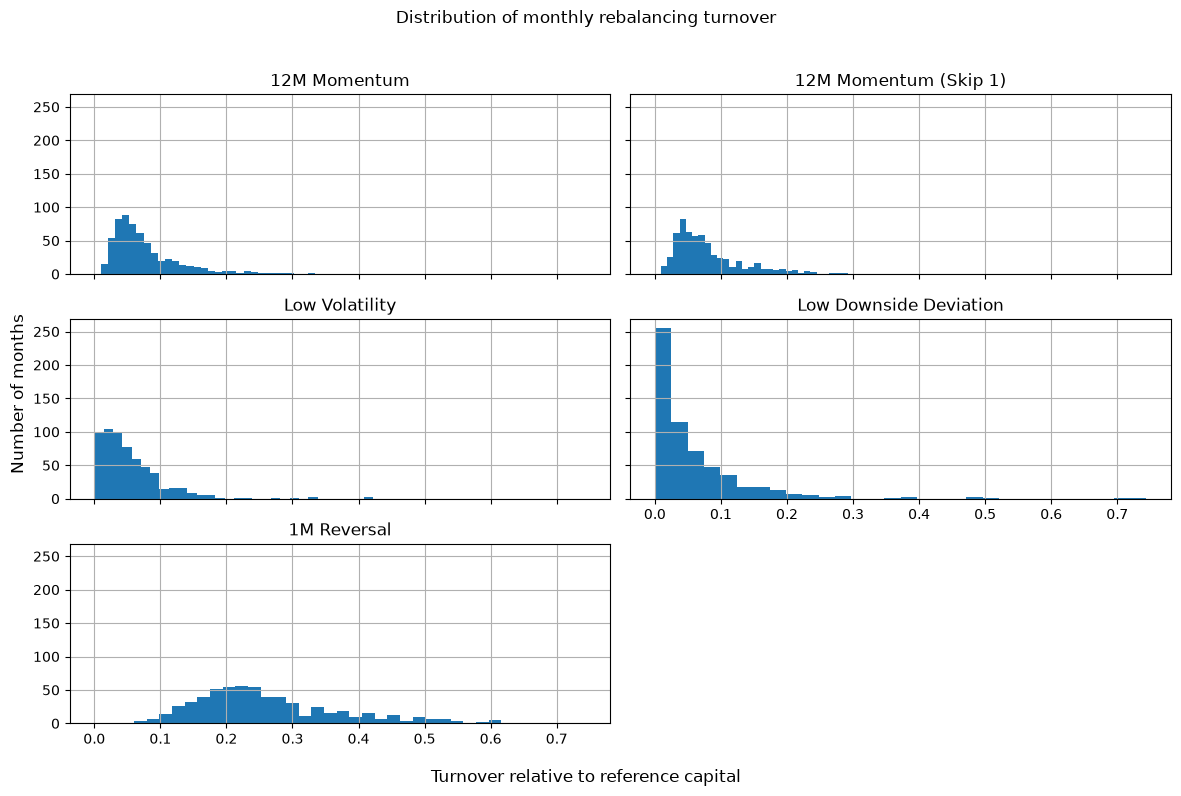

In [14]:
# Histogram for turnover
axes = turnover_recurrent_df.hist(bins=30, figsize=(12, 8), sharex=True, sharey=True)

plt.suptitle('Distribution of monthly rebalancing turnover')
plt.gcf().supxlabel('Turnover relative to reference capital')
plt.gcf().supylabel('Number of months')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The turnover distributions differ substantially across signals. The two momentum portfolios have average monthly turnover of approximately 0.08, while the low-volatility and low-downside-deviation portfolios have lower averages of approximately 0.05 and 0.06, respectively.

The one-month reversal strategy is substantially more active, with average monthly turnover of approximately 0.26 and median turnover of 0.24. The closeness of its mean and median suggests that its higher turnover is persistent rather than being driven only by a few unusually large rebalances.

The low-downside-deviation portfolio displays a different pattern. Its median monthly turnover is only 0.03, but its maximum reaches approximately 0.74, indicating that relatively infrequent large changes in target exposure account for part of its average turnover.

These differences are economically important because, under the transaction-cost model used here, the return drag from trading is directly proportional to turnover.

In [15]:
cost_bps = [0, 1, 2, 5]

after_cost = []
for factor, gross_r in target_vol_returns.items():
    # Turnover calculated at end of t establishes positions for t+1
    factor_turnover = turnover[factor].shift(1)
    factor_turnover_return = pd.concat([gross_r.rename('gross_return'), factor_turnover.rename('turnover')], axis=1).dropna()

    for bp in cost_bps:
        cost_rate = bp / 10_000
        net_r = factor_turnover_return['gross_return'] - cost_rate * factor_turnover_return['turnover']
        ann_return = net_r.mean() * 12
        ann_vol = net_r.std(ddof=1) * np.sqrt(12)
        sharpe = ann_return / ann_vol
        final_pnl = capital * net_r.sum()

        after_cost.append({
            'Factor': factor_names[factor],
            'Cost Assumption (bps)': bp,
            'Annualized Mean Return': ann_return,
            'Realized Annualized Volatility': ann_vol,
            'Sharpe Ratio': sharpe,
            'Final Cumulative P&L': final_pnl
        })

cost_df = pd.DataFrame(after_cost).set_index(['Factor', 'Cost Assumption (bps)'])

In [16]:
cost_df.style.format({
    'Annualized Mean Return': '{:.2%}',
    'Realized Annualized Volatility': '{:.2%}',
    'Sharpe Ratio': '{:.2f}',
    'Final Cumulative P&L': '${:,.0f}'
})

The transaction-cost sensitivity results are consistent with the turnover estimates. The momentum strategies deteriorate gradually as assumed costs rise, while the one-month reversal strategy is substantially more sensitive because it requires much larger changes in target exposure each month.

At an assumed cost of 5 basis points per dollar of rebalanced notional, the one-month reversal portfolio's annualized mean return falls from approximately 0.19% to 0.03%, and its Sharpe ratio falls from 0.19 to 0.03. In contrast, both momentum specifications retain positive mean returns and materially positive Sharpe ratios under the same cost assumption.

The negative performance of the low-volatility strategy is not explained by transaction costs, since its gross return is already negative before costs are applied. The downside-deviation specification remains modestly positive under the tested assumptions, although its already weak gross performance is further reduced.

Realized volatility changes very little across the cost scenarios. At these cost levels, the primary effect of transaction costs is therefore a reduction in average return rather than a material change in overall return volatility.

### 6.4 Factor Dependence and U.S. Equity Exposure

Standalone performance does not determine whether a factor is useful in a diversified portfolio. A factor with a relatively weak average return may still contribute if its returns behave differently from those of other factors.

I therefore examine the realized correlation matrix of the five factor return series.

I also compare each factor with the supplied U.S. equity-index-futures return series using correlation and beta. For factor return $R_F$ and U.S. return $R_{US}$,

$$
\beta_F
=
\frac{
\operatorname{Cov}(R_F,R_{US})
}{
\operatorname{Var}(R_{US})
}.
$$

Correlation measures the strength of linear co-movement independent of scale, while beta also reflects the relative volatility of the two return series. Because the factor portfolios are deliberately targeted to approximately 1% annualized volatility, their betas may be small partly because their overall risk level is much lower than that of the U.S. equity return series.

In [17]:
factor_returns_df = pd.DataFrame(target_vol_returns).rename(columns=factor_names)
factor_corr = factor_returns_df.corr()
factor_corr.style.format('{:.2f}')

,12M Momentum,12M Momentum (Skip 1),Low Volatility,Low Downside Deviation,1M Reversal
12M Momentum,1.00,0.96,0.11,0.53,-0.32
12M Momentum (Skip 1),0.96,1.00,0.08,0.48,-0.14
Low Volatility,0.11,0.08,1.00,0.72,-0.05
Low Downside Deviation,0.53,0.48,0.72,1.00,-0.27
1M Reversal,-0.32,-0.14,-0.05,-0.27,1.00


In [18]:
us_returns = returns['USA']

market_exposure = []
for factor, r in target_vol_returns.items():
    factor_us = pd.concat([r.rename('factor'), us_returns.rename('US Equity')], axis=1).dropna()
    factor_us_corr = factor_us['factor'].corr(factor_us['US Equity'])
    beta = factor_us['factor'].cov(factor_us['US Equity']) / factor_us['US Equity'].var()

    market_exposure.append({
        'Factor': factor_names[factor],
        'Correlation with US Equity': factor_us_corr,
        'Beta to US Equity': beta
    })

market_exposure_df = pd.DataFrame(market_exposure).set_index('Factor')

In [19]:
market_exposure_df

,Correlation with US Equity,Beta to US Equity
Factor,,
12M Momentum,-0.039715,-0.002854
12M Momentum (Skip 1),-0.027509,-0.001983
Low Volatility,-0.153414,-0.009686
Low Downside Deviation,-0.113617,-0.007612
1M Reversal,-0.003374,-0.000221


The correlation structure supports treating the five specifications as implementations of three broader factor families rather than as five independent
sources of return.

The two momentum portfolios have a correlation of 0.96, indicating that skipping the most recent month changes the implementation but leaves the underlying return pattern largely unchanged. Similarly, the two low-risk specifications have a relatively high correlation of 0.72, although the difference is large enough to suggest that total volatility and downside deviation capture somewhat different aspects of cross-sectional risk.

Short-term reversal is the most distinct signal. Its correlations with all four other portfolios are negative, ranging from approximately -0.05 to -0.32. Its standalone Sharpe ratio does not by itself capture its potential diversification value: a lower-return component can still improve the risk characteristics of a combination when its returns differ sufficiently from those of the other components.

The factor portfolios also exhibit little realized co-movement with the supplied U.S. equity return series. Correlations range from approximately zero to -0.15, and estimated betas are very small in magnitude. The small beta estimates partly reflect the much lower volatility scale of the factor portfolios, so correlation is the more directly comparable measure of co-movement here. Overall, the results are consistent with the portfolios behaving primarily as relative-value cross-sectional strategies rather than as directional U.S. equity exposures.

### 6.5 Three-Signal Portfolio

The five specifications considered above include alternative implementations of
the same broad factor ideas. For the final diversification exercise, I select one
representative signal from each of three distinct categories rather than combining
all five specifications.

The selected signals are:

- **12M Momentum (Skip 1):** represents medium-horizon momentum while excluding
  the most recent month's return, helping separate the momentum signal from
  short-term reversal.

- **Low Downside Deviation:** represents the low-risk hypothesis using downside
  rather than total return variation. The alternative low-volatility
  specification produced negative performance over the observed sample, so it
  is not included in the illustrative combination.

- **1M Reversal:** represents short-term reversal and exhibits negative correlations
  with the other factor portfolios.

The two momentum specifications are highly correlated, so including both would
largely duplicate the same source of portfolio exposure. Similarly, the purpose
of the final portfolio is to combine distinct signal ideas rather than to assign
additional weight to factor families for which multiple specifications happened
to be tested.

Each selected portfolio has already been individually scaled to a predicted
annualized volatility of 1%. I therefore begin by equally weighting the three
selected portfolios:

$$
w^{C,\mathrm{raw}}_{t+1}
=
\frac{1}{3}
\left(
\tilde w^{M\text{-skip}}_{t+1}
+
\tilde w^{DD}_{t+1}
+
\tilde w^{R}_{t+1}
\right).
$$

Because diversification generally causes the volatility of this average to be
less than the volatility of its individual components, the combined portfolio is
then rescaled using the same rolling covariance estimate to a predicted
annualized volatility of 1%.

This signal selection is made after examining the full-sample standalone
results. The combined portfolio should therefore be interpreted as an
illustrative in-sample portfolio-construction exercise rather than as an
independent out-of-sample test of a pre-specified strategy.

In [20]:
# Compute combined portfolio returns
combined_raw_weights = (scaled_weights['mmtm_12m_skip1'] + scaled_weights['low_dd'] + scaled_weights['rev']) / 3
combined_weights = scale_to_target_vol(combined_raw_weights, cov_36m_ann, target_vol=0.01)
combined_returns = (combined_weights.shift(1) * returns).sum(axis=1, min_count=1)

In [21]:
selected_returns = {
    '12M Momentum (Skip 1)': target_vol_returns['mmtm_12m_skip1'],
    'Low Downside Deviation': target_vol_returns['low_dd'],
    '1M Reversal': target_vol_returns['rev'],
    'Combined Portfolio': combined_returns
}

selected_stats = {}
for portfolio, r in selected_returns.items():
    r = r.dropna()
    n_months = len(r)

    ann_return = r.mean() * 12
    ann_vol = r.std(ddof=1) * np.sqrt(12)
    sharpe = ann_return / ann_vol
    t_stat = r.mean() / (r.std(ddof=1) / np.sqrt(n_months))
    
    portfolio_pnl = capital * r.cumsum()
    portfolio_pnl = pd.concat([
        pd.Series([0.0], index=[r.index[0] - pd.offsets.MonthEnd(1)]),
        portfolio_pnl
    ])
    running_max_pnl = portfolio_pnl.cummax()
    pnl_drawdown = portfolio_pnl - running_max_pnl
    max_pnl_drawdown_pct = pnl_drawdown.min() / capital
    final_pnl = portfolio_pnl.iloc[-1]

    selected_stats[portfolio] = {
        'Annualized Arithmetic Return': ann_return,
        'Realized Annualized Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Mean Return t-Statistic': t_stat,
        'Max PnL Drawdown / Reference Capital': max_pnl_drawdown_pct,
        'Final Cumulative PnL': final_pnl
    }

# Convert into DataFrame
selected_stats_df = pd.DataFrame.from_dict(selected_stats, orient='index')
selected_stats_df.index.name = 'Portfolio'
selected_stats_df.style.format({
    'Annualized Arithmetic Return': '{:.2%}',
    'Realized Annualized Volatility': '{:.2%}',
    'Sharpe Ratio': '{:.2f}',
    'Mean Return t-Statistic': '{:.2f}',
    'Max PnL Drawdown / Reference Capital': '{:.2%}',
    'Final Cumulative PnL': '${:,.0f}'
})

,Annualized Arithmetic Return,Realized Annualized Volatility,Sharpe Ratio,Mean Return t-Statistic,Max PnL Drawdown / Reference Capital,Final Cumulative PnL
Portfolio,,,,,,
12M Momentum (Skip 1),0.32%,1.12%,0.28,2.00,-3.72%,"$158,349"
Low Downside Deviation,0.07%,1.04%,0.07,0.50,-3.73%,"$37,149"
1M Reversal,0.19%,1.02%,0.19,1.32,-6.25%,"$94,699"
Combined Portfolio,0.28%,1.07%,0.26,1.86,-3.51%,"$140,834"


The combined portfolio produces an annualized arithmetic return of 0.28% with realized annualized volatility of 1.07%, remaining close to the 1% ex-ante volatility target. Its Sharpe ratio is 0.26 and its mean-return t-statistic is 1.86.

The combined portfolio does not outperform the skip-one-month momentum strategy on either average return or Sharpe ratio. The momentum portfolio earns 0.32% annually with a Sharpe ratio of 0.28, compared with 0.28% and 0.26 for the combination. This is not surprising because the low-downside-deviation signal has a much weaker standalone return, while combining the strategies gives each selected signal equal weight before the final volatility rescaling.

The main benefit of the combination appears instead in the shape of the return path. Its maximum cumulative-P&L drawdown is approximately -3.51% of reference capital, slightly smaller than the -3.72% drawdown of the momentum portfolio and substantially smaller than the -6.25% drawdown of the reversal portfolio. Thus, diversification reduces the severity of the worst historical drawdown while retaining most of the stronger momentum signal's average return.

Short-term reversal contributes a different source of return variation, as suggested by its negative correlations with the other selected signals. Low downside deviation also provides a distinct, although comparatively weak, component. Their inclusion therefore changes the portfolio's risk profile even though neither improves the standalone return statistics relative to momentum.

The combined portfolio's t-statistic of 1.86 remains below conventional levels typically associated with strong evidence against a zero expected return, and is lower than the approximately 2.00 statistic for skip-one-month momentum alone. The combination should therefore be viewed primarily as an illustration of diversification across distinct signals rather than as evidence that combining the factors produces a statistically stronger return premium.

Finally, the signal selection and combination were constructed after examining the standalone full-sample results. In particular, the total-volatility specification was excluded after its poor historical performance was observed. The combined-portfolio results are therefore descriptive and in-sample, rather than an independent test of a portfolio rule specified before observing the data.

## 7. Limitations, Further Work, and Conclusion

This project examined cross-sectional momentum, low-risk, and short-term reversal signals across ten developed-country equity index futures within a common portfolio-construction framework. Each signal was transformed into a dollar-neutral portfolio and scaled using a rolling covariance estimate to a predicted annualized volatility target of 1%. The resulting portfolios were evaluated using realized returns, cumulative P&L, turnover, transaction-cost sensitivity, factor dependence, and an illustrative multi-signal combination.

The strongest standalone results in the sample come from momentum. Both momentum specifications produce positive average returns, with the skip-most-recent-month specification showing the highest Sharpe ratio and mean-return t-statistic among the tested signals. Short-term reversal also produces a positive gross return, but its substantially higher turnover makes it much more sensitive to assumed transaction costs. The total-volatility low-risk specification produces a negative return, while the downside-deviation specification produces a weak but positive result.

One limitation in interpreting the low-risk results is that the portfolios are constructed to be dollar-neutral, but not necessarily market-beta-neutral. A strategy that is long lower-risk markets and short higher-risk markets may still carry systematic market exposure if the two groups differ in their market sensitivities. Consistent with this possibility, the low-volatility portfolio has the most negative realized correlation with the supplied U.S. equity return series among the five strategies, at approximately -0.15. This does not establish the source of its negative performance, but it suggests that some of the result may reflect unintended market exposure rather than the low-risk signal alone. Further investigation of the low-risk factor could therefore help separate these effects.

Several other extensions could strengthen the analysis. Statistical inference could account for serial correlation and heteroskedasticity using HAC or Newey-West standard errors rather than the conventional iid t-statistics used here. Performance could also be examined across subperiods to assess whether the signals are stable across different market regimes. In particular, the short-term reversal results appear to change materially after approximately 2014, which would merit a more formal regime or subperiod analysis.

Most importantly, a genuine out-of-sample test could separate signal selection from performance evaluation and provide a cleaner assessment of whether the observed relationships persist beyond the sample used to develop the specifications.

Implementation analysis could also be extended with more detailed futures data. The supplied return series do not provide sufficient information to reconstruct contract rolls, collateral returns, margin requirements, contract multipliers, or historical execution costs. Access to these data would permit a more realistic futures implementation and transaction-cost model. Alternative covariance estimators, leverage constraints, position limits, and a broader market universe could also be investigated.

The final three-signal portfolio combines skip-one-month momentum, low downside deviation, and short-term reversal. It does not improve upon momentum's standalone Sharpe ratio, but it produces a somewhat smaller historical drawdown while maintaining similar realized volatility and much of the momentum portfolio's average return. Because the signal selection and combination were constructed after examining the standalone full-sample results, the combined portfolio should be interpreted as an illustrative in-sample diversification exercise rather than as independent evidence of superior out-of-sample performance.

These extensions are intentionally left outside the scope of the current project. The objective is not to search for the historically optimal specification, but to demonstrate a transparent research process: define economically interpretable signals, construct portfolios without look-ahead bias, control portfolio risk, report negative as well as positive results, account for basic implementation costs, and distinguish standalone factor performance from diversification and systematic market exposure.